# Paper-exact reproduction: the addition circuit on Qwen3-4B

Reproduces **every** experiment of the biology paper's Addition dive
([biology.html §Addition](https://transformer-circuits.pub/2025/attribution-graphs/biology.html#dives-addition))
plus the methods-supplement interventions quoted there, on Qwen3-4B with
`mwhanna/qwen3-4b-transcoders` (per-layer). Paper reference values live in
`notes/biology_digest.md` (§A); the per-experiment verdict table is at the bottom and in
`DEVLOG.md`.

**Protocol notes**
- The paper's raw completion format `calc: a+b=` is used throughout (10,000-prompt operand
  grids, feature activity on the `=` token), with a chat fallback only if its accuracy
  collapses (it doesn't: ~78%).
- Qwen3 tokenizes numbers **digit-by-digit**, so the paper's single-token answer circuit
  splits into two per-digit circuits: the *first/magnitude* digit (plain prompt) and the
  *ones* digit (teacher-forced prefix). Position-sensitive experiments (operand grids,
  the Polymer reuse test) must be probed at the matching per-digit moment.
- The paper studies a prompt the model answers **correctly** (Haiku: 36+59). Qwen3-4B gets
  `calc: 36+59=` wrong, so the studied pair auto-switches to the nearest correct pair with
  the same digit classes (a%10, b%10, a+b preserved → the same `_6+_9 → sum=_95` structure).
- Steering conventions: the paper's multiple **M** is multiplicative (`a_new = M·a_clean`);
  our `m` is additive-delta (`m = M−1`): ablation M=0 ⇒ m=−1, sign-flip M=−1 ⇒ m=−2, paper
  "−2×" ⇒ m=−3.

All machinery lives in `addition_helper.py`; artifacts (explorer HTMLs, PNGs, JSONs) land
in `artifacts/paper_addition/<size>/`. Executed end-to-end on an A100-80GB (~35 min).

In [1]:
%matplotlib inline
import json

import addition_helper as A
import matplotlib.pyplot as plt
import numpy as np
import torch

from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.settings import artifacts_dir, default_device
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder

SIZE = "4b"
DEVICE = default_device()
OUT = artifacts_dir() / "paper_addition" / SIZE
OUT.mkdir(parents=True, exist_ok=True)

model, tokenizer = load_qwen3(SIZE, dtype_str="bf16", device_map=DEVICE)
model.eval()
tc = load_transcoder(f"qwen3-{SIZE}", device=DEVICE, dtype=torch.bfloat16).transcoder
N_LAYERS = len(tc)
A_VALS = list(range(100))
B_VALS = list(range(100))
print(f"Qwen3-{SIZE} on {DEVICE}; {N_LAYERS} transcoder layers; artifacts -> {OUT}")

[07/09/26 23:30:47] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/models)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[07/09/26 23:30:52] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/transcoders)

Qwen3-4b on cuda; 36 transcoder layers; artifacts -> /teamspace/studios/this_studio/llm-circuits/artifacts/paper_addition/4b


## 0. Accuracy on the paper's 10,000-prompt grid + studied-pair selection

The paper computes operand plots over all `calc: a+b=` for a, b ∈ [0, 99]. We first check
the model can do the task in this format (gate: ≥50%, else fall back to the chat format and
report that), then pick the studied pair: the paper's 36+59 if correct, otherwise the
nearest correct same-digit-class pair.

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


accuracy[calc] = 77.7%
_6+_9 class accuracy: 46.0%; correct[36,59] = False
studied pair: 46+49=95 (SWITCHED from 36+59 — the model answers the paper's pair incorrectly)


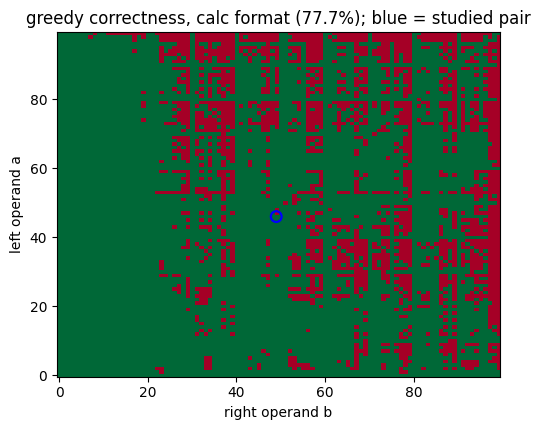

In [2]:
correct, _pred = A.accuracy_grid(model, tokenizer, A_VALS, B_VALS, style="calc")
acc_calc = float(correct.mean())
print(f"accuracy[calc] = {acc_calc:.1%}")
STYLE = "calc"
if acc_calc < 0.5:  # paper-format fallback (not needed for 4b)
    correct, _pred = A.accuracy_grid(model, tokenizer, A_VALS, B_VALS, style="chat")
    STYLE = "chat"
    print(f"accuracy[chat] = {float(correct.mean()):.1%} -> falling back to chat format")
np.save(OUT / f"accuracy_{STYLE}.npy", correct)

class69 = np.mean(
    [correct[a, b] for a in range(100) for b in range(100) if a % 10 == 6 and b % 10 == 9]
)
print(f"_6+_9 class accuracy: {class69:.1%}; correct[36,59] = {bool(correct[36, 59])}")
A0, B0, switched = A.pick_studied_pair(36, 59, correct)
print(
    f"studied pair: {A0}+{B0}={A0 + B0}"
    + (
        " (SWITCHED from 36+59 — the model answers the paper's pair incorrectly)"
        if switched
        else ""
    )
)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.imshow(correct, origin="lower", cmap="RdYlGn", aspect="auto", interpolation="nearest")
ax.scatter([B0], [A0], s=60, facecolors="none", edgecolors="blue", linewidths=1.6)
ax.set_xlabel("right operand b")
ax.set_ylabel("left operand a")
ax.set_title(
    f"greedy correctness, {STYLE} format ({float(correct.mean()):.1%}); blue = studied pair"
)
plt.tight_layout()
plt.show()

## A. Attribution graphs — the two per-digit circuits (Fig A2)

The paper's graph runs from the prompt to the single answer token "95". With digit-split
tokenization we build two graphs: `target="first"` attributes the argmax next token after
`=` (the magnitude digit, expect `9`), and `target="ones"` teacher-forces the leading
digit(s) and attributes the ground-truth ones digit (expect `5`). Interactive explorer
HTMLs are written next to this notebook's other artifacts.

In [3]:
graphs, answers, ids = {}, {}, {}
for target in ("first", "ones"):
    d, aid, iid = A.build_addition_graph(
        model,
        tc,
        tokenizer,
        A0,
        B0,
        target=target,
        style=STYLE,
        size_key=SIZE,
        max_feature_nodes=8000,
        out_html=str(OUT / f"graph_{A0}p{B0}_{target}.html"),
    )
    graphs[target], answers[target], ids[target] = d, aid, iid
    nfeat = sum(1 for n in d["nodes"] if n["node_type"] == "feature")
    print(
        f"graph[{target}]: answer={tokenizer.decode([aid])!r}, {nfeat} feature nodes "
        f"-> graph_{A0}p{B0}_{target}.html"
    )

[07/09/26 23:31:32] INFO     Selected 10 logits with cumulative probability 0.9570

/teamspace/studios/this_studio/llm-circuits/src/llm_circuits/circuits/attribution_graph.py:486: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  prob=float(top_p[rank]),  # actual prob (influence seed; sums to ~desired_prob)


                    INFO     Built 8344 nodes (emb=10, feat=8000, err=324, logit=10)

                    INFO     Pre-computing source contribution vectors ...

                    INFO       layer 0: 179 feature contributions computed

...

                    WARNING  Failed to load label for layer 34 feature 15971: No gzip magic found in feature blob  
                             at index 15971

                    WARNING  Failed to load label for layer 34 feature 28807: No gzip magic found in feature blob  
                             at index 28807

                    WARNING  Failed to load label for layer 35 feature 10607: No gzip magic found in feature blob  
                             at index 10607

                    WARNING  Failed to load label for layer 35 feature 154698: No gzip magic found in feature blob 
                             at index 154698

graph[ones]: answer='5', 1347 feature nodes -> graph_46p49_ones.html


## B. Operand grids + taxonomy (Fig A1)

Feature activity over all 10,000 prompts, probed at each feature's **functional position**:
answer features of the first-digit circuit at the `=` token (plain prompt), answer/mid-layer
features of the ones circuit at the teacher-forced predict-ones position, and **input-token
features at their peak over prompt positions** (they are silent at the final position).
Input supernodes are selected from **early layers** (< n_layers/4) of the ones graph at the
operand digit positions — the paper's `_6`/`_9`/`~magnitude` input features are
detokenization-level, and without the layer cap late-layer aggregation features crowd them
out of the influence ranking.

Paper taxonomy to look for: **diagonals** = sum features, **isolated/repeating points** =
lookup-table features, **repeating stripes** = mod-10, **smears** = low-precision,
**horizontal/vertical stripes** = single-operand sensitivity.

The `add_function` group probes the paper's remaining input class: features living on
the `+`/`=` operator tokens (mid-level, between detokenization and the lookups they
feed). Expected operand plot: largely operand-independent (uniform/stripes), unlike
the digit-selective input classes.


In [4]:
groups = {}
groups["answer_first"] = [
    (f["layer"], f["feature_idx"])
    for f in A.answer_features(graphs["first"], top_k=8, numeric_only=True)
]
groups["answer_ones"] = [
    (f["layer"], f["feature_idx"])
    for f in A.answer_features(graphs["ones"], top_k=8, numeric_only=True)
]

mid = [
    n
    for n in graphs["ones"]["nodes"]
    if n["node_type"] == "feature" and N_LAYERS // 4 <= n["layer"] < 3 * N_LAYERS // 4
]
mid.sort(key=lambda n: n.get("influence", 0.0), reverse=True)
groups["midlayer"] = [(n["layer"], n["feature_idx"]) for n in mid[:16]]

pos = A.digit_token_positions(tokenizer, ids["ones"], A0, B0)
lmax_input = max(1, N_LAYERS // 4)
groups["input_a"] = [
    (L, i)
    for (L, i, _) in A.position_features(graphs["ones"], pos["a_digits"], 16, max_layer=lmax_input)
]
groups["input_b"] = [
    (L, i)
    for (L, i, _) in A.position_features(graphs["ones"], pos["b_digits"], 16, max_layer=lmax_input)
]
# the paper's ADD-FUNCTION class: features living on the +/= operator tokens (no layer
# cap — they sit mid-level, between the detokenized operands and the lookups they feed)
groups["add_function"] = [
    (L, i) for (L, i, _) in A.position_features(graphs["ones"], pos["plus"] + pos["eq"], 16)
]

all_feats = sorted({f for g in groups.values() for f in g})
print(
    f"probing {len(all_feats)} features x 3 probe modes over {len(A_VALS) * len(B_VALS)} prompts ..."
)
probe_first = "last" if STYLE == "calc" else "first"
grids_first = A.feature_grids(
    model, tc, all_feats, A_VALS, B_VALS, tokenizer, probe=probe_first, style=STYLE
)
grids_ones = A.feature_grids(
    model, tc, all_feats, A_VALS, B_VALS, tokenizer, probe="ones", style=STYLE
)
grids_peak = (
    grids_first
    if probe_first == "first"
    else A.feature_grids(
        model, tc, all_feats, A_VALS, B_VALS, tokenizer, probe="first", style=STYLE
    )
)


def grids_for(gname):
    if gname in ("answer_ones", "midlayer"):
        return grids_ones
    if gname in ("input_a", "input_b", "add_function"):
        return grids_peak  # operand/operator-token features are silent at the final position
    return grids_first


taxonomy = {}
for gname, feats in groups.items():
    taxonomy[gname] = {
        f"L{L}f{i}": A.periodicity_report(grids_for(gname)[(L, i)], A_VALS, B_VALS)
        for (L, i) in feats
    }
    counts = {}
    for rep in taxonomy[gname].values():
        key = str(rep["label"]).split("(")[0]
        counts[key] = counts.get(key, 0) + 1
    print(f"taxonomy[{gname}]: {counts}")

probing 68 features x 3 probe modes over 10000 prompts ...


taxonomy[answer_first]: {'mixed': 7, 'magnitude-diag': 1}
taxonomy[answer_ones]: {'mixed': 3, 'mod10-sum': 4, 'lookup': 1}


taxonomy[midlayer]: {'lookup': 5, 'mixed': 7, 'sparse': 2, 'mod10-sum': 1, 'inactive': 1}


taxonomy[input_a]: {'mixed': 5, 'lookup': 10}


taxonomy[input_b]: {'lookup': 8, 'mixed': 3, 'mod10-b': 1}


taxonomy[add_function]: {'mixed': 15, 'lookup': 1}


In [5]:
sel = {}
sel["lookup"] = A.select_from_reports(
    taxonomy["midlayer"], lambda r: str(r["label"]).startswith("lookup")
) + A.select_from_reports(taxonomy["answer_ones"], lambda r: str(r["label"]).startswith("lookup"))
sel["sum"] = A.select_from_reports(
    taxonomy["answer_ones"], lambda r: str(r["label"]).startswith("mod10-sum")
)
sel["input_6"] = A.select_from_reports(
    taxonomy["input_a"],
    lambda r: str(r["label"]).startswith(("mod10-a", "lookup")) and r.get("a_top") == A0 % 10,
)
sel["input_9"] = A.select_from_reports(
    taxonomy["input_b"],
    lambda r: str(r["label"]).startswith(("mod10-b", "lookup")) and r.get("b_top") == B0 % 10,
)
sel["input_mag"] = A.select_from_reports(
    taxonomy["input_a"], lambda r: str(r["label"]) in ("magnitude-diag", "mixed")
) + A.select_from_reports(
    taxonomy["input_b"], lambda r: str(r["label"]) in ("magnitude-diag", "mixed")
)
print("selection sizes:", {k: len(v) for k, v in sel.items()})
(OUT / "taxonomy.json").write_text(
    json.dumps(
        {"taxonomy": taxonomy, "selections": {k: [list(x) for x in v] for k, v in sel.items()}},
        indent=1,
        default=str,
    )
)

selection sizes: {'lookup': 6, 'sum': 4, 'input_6': 6, 'input_9': 6, 'input_mag': 8}


24065

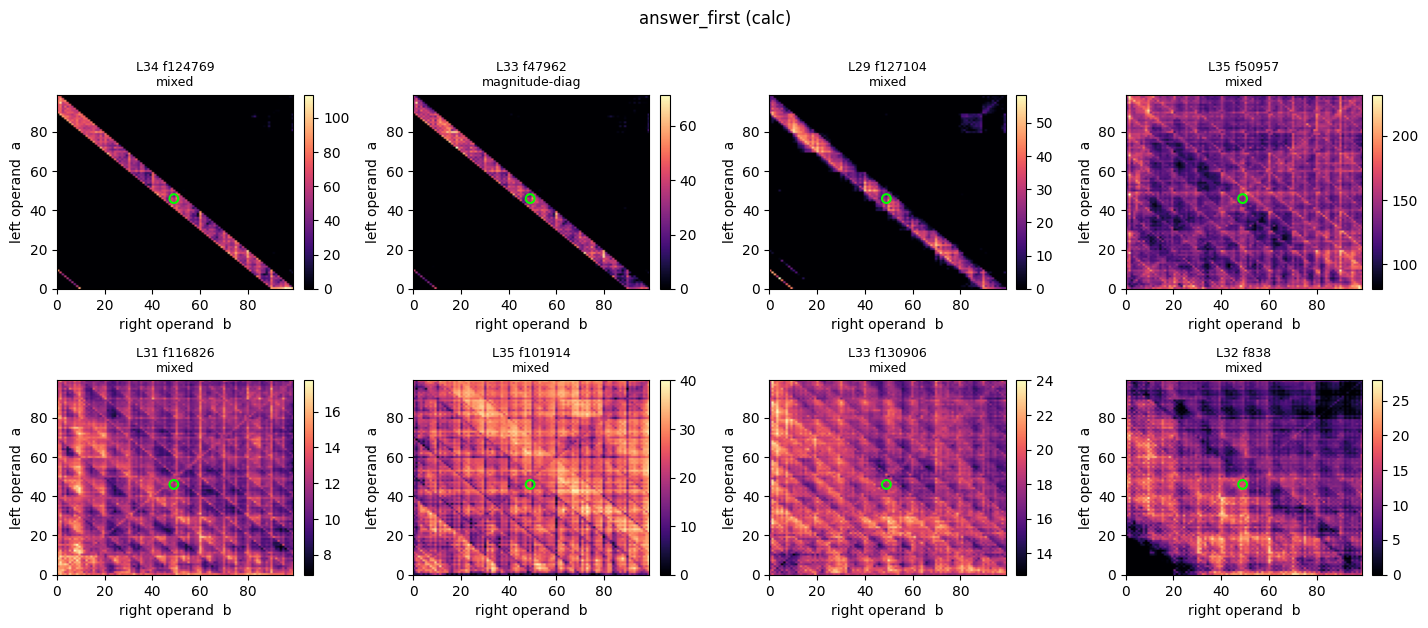

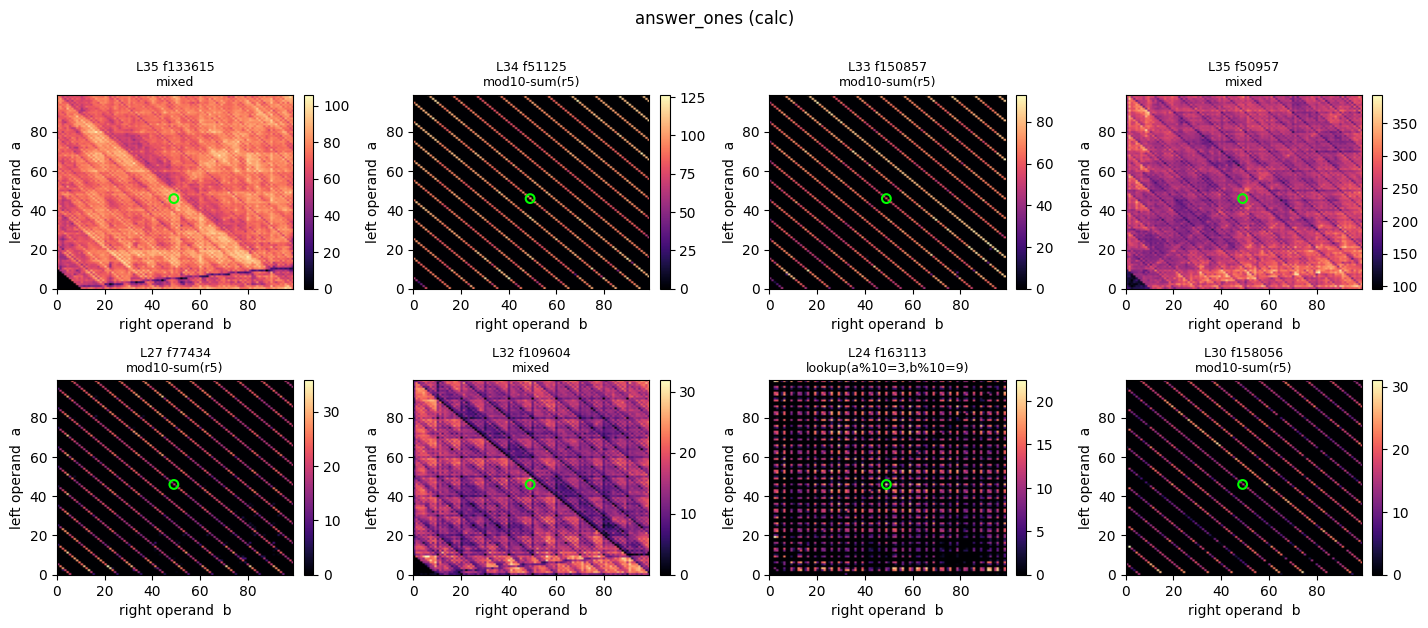

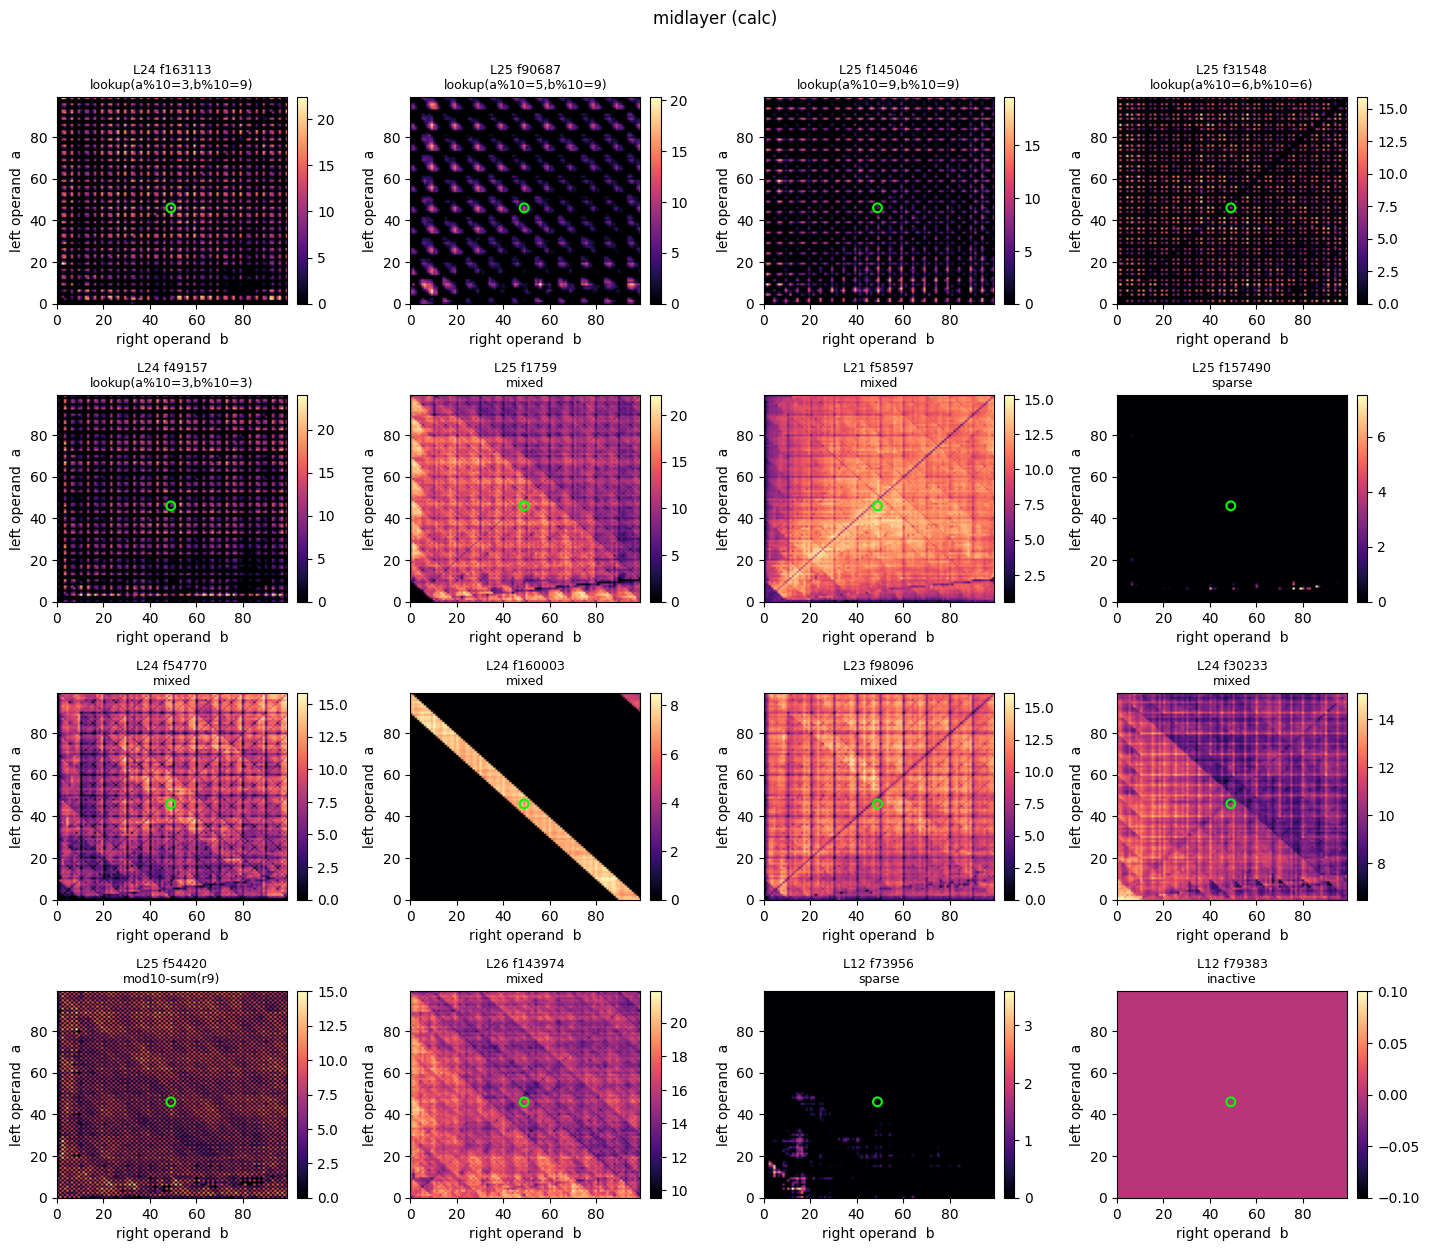

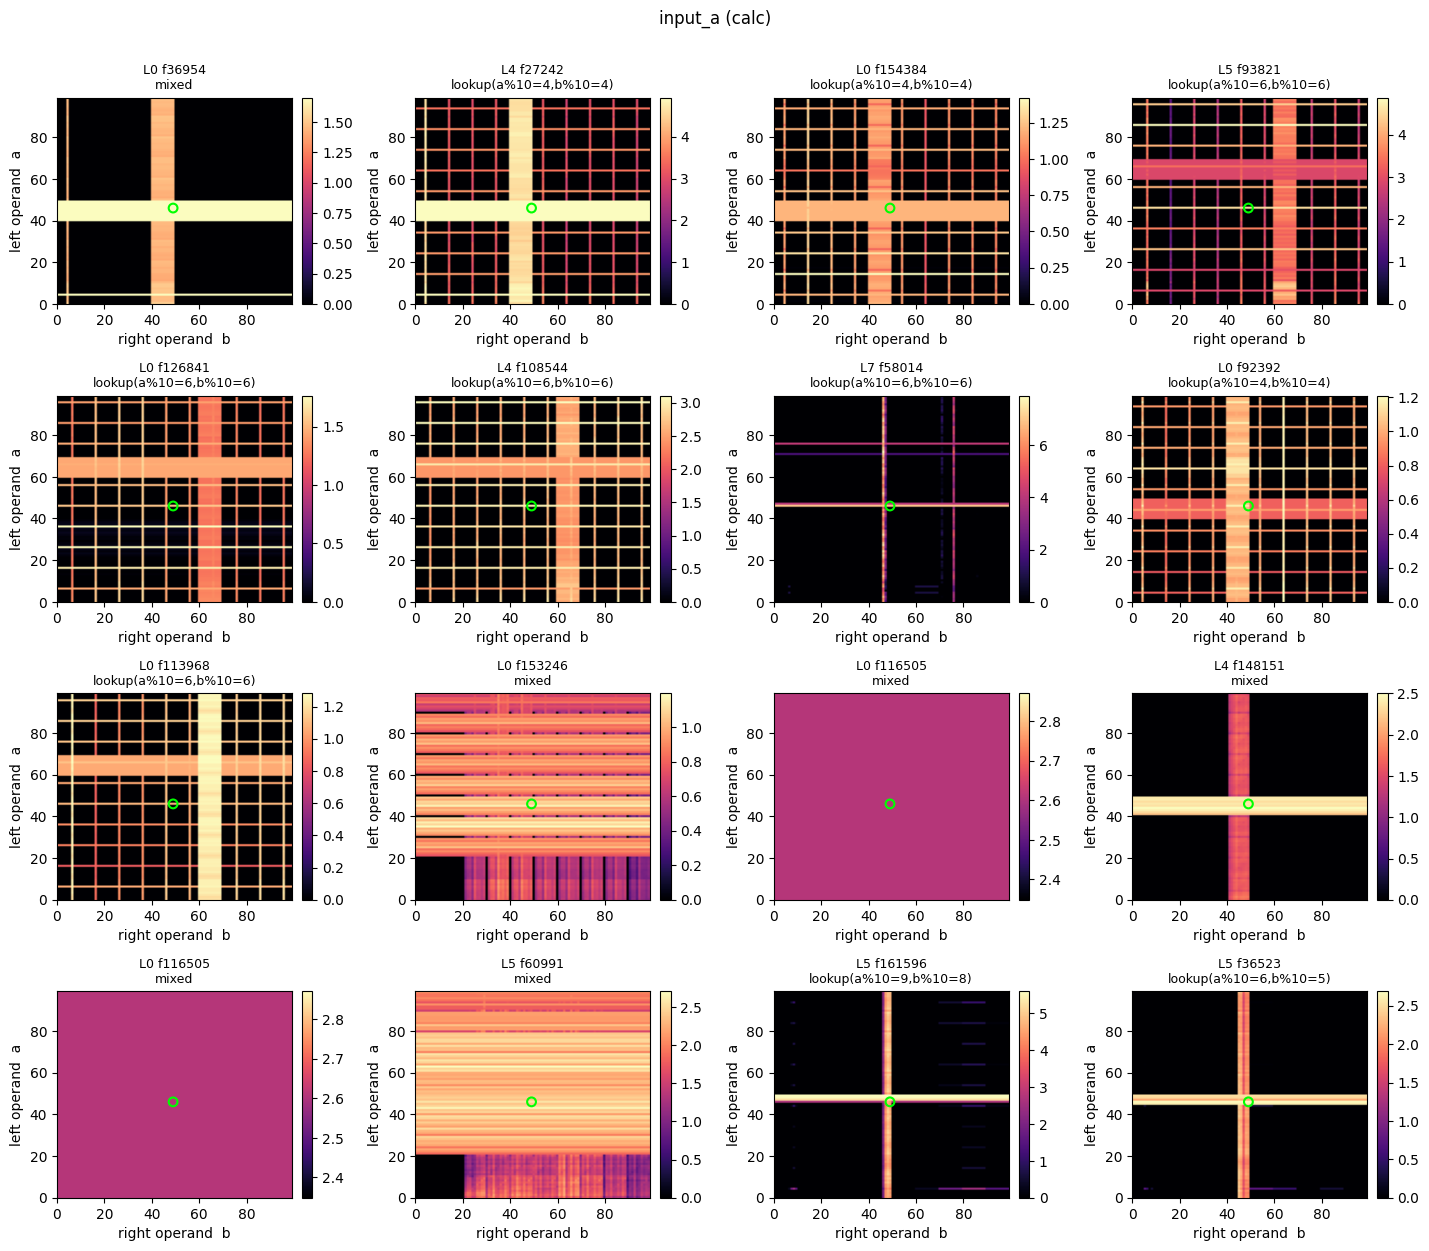

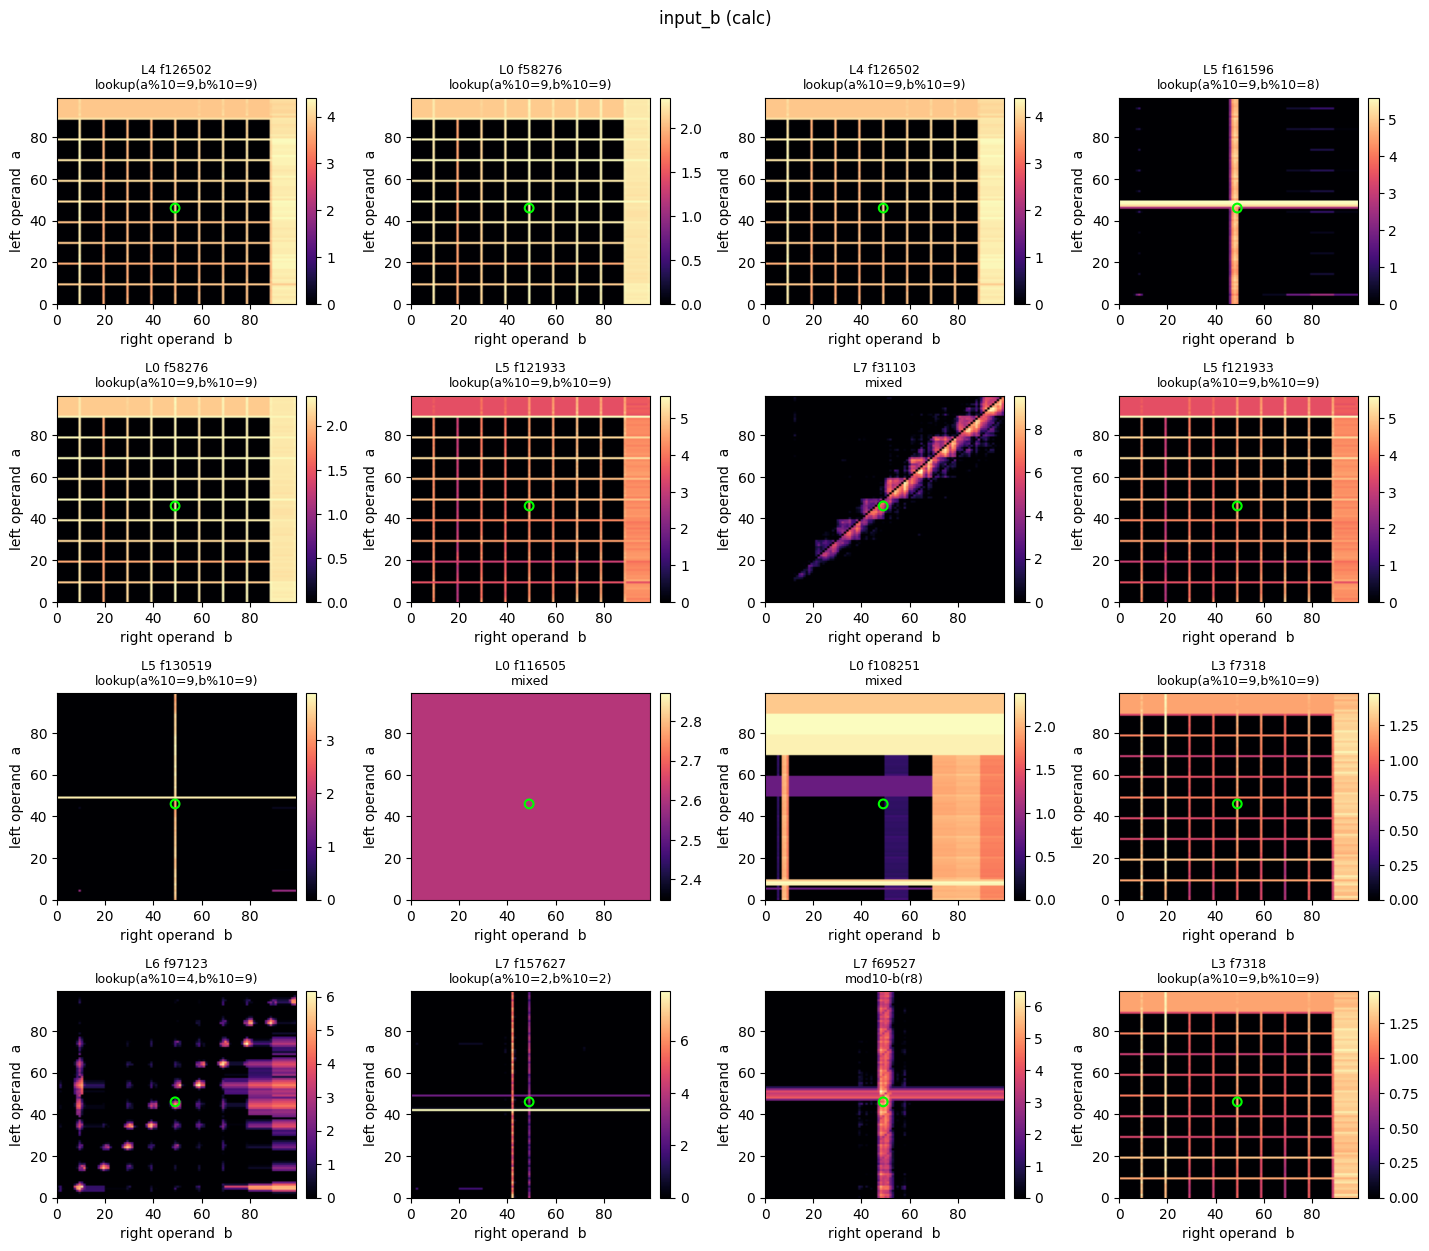

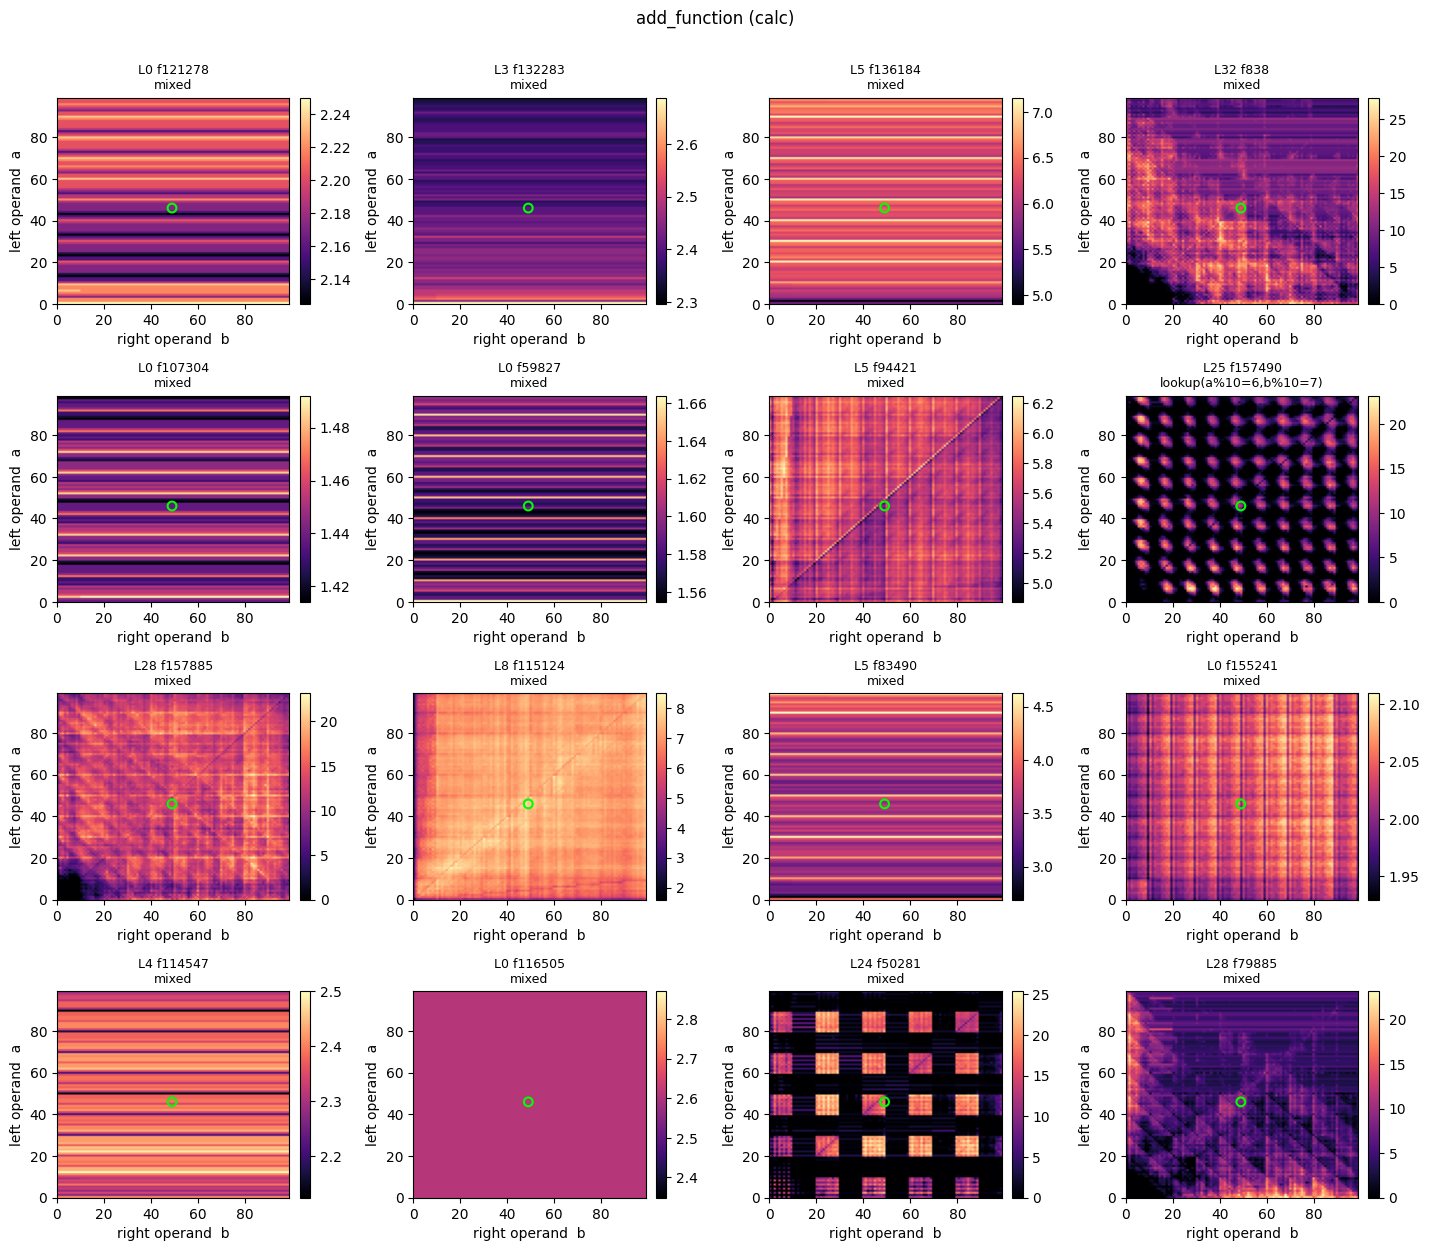

In [6]:
for gname, feats in groups.items():
    if not feats:
        continue
    fig = A.plot_grid_panels(
        feats,
        grids_for(gname),
        A_VALS,
        B_VALS,
        mark=(A0, B0),
        title=f"{gname} ({STYLE})",
        path=OUT / f"grids_{gname}.png",
    )
    plt.show()

## C. Input-supernode suppressions (methods supplement)

Paper outcomes on 36+59: suppress `_6` → output **98** (the ones circuit computes 9+9);
suppress `_9` → **91** ("not 92, so such numerology must be taken with a grain of salt");
inhibit the `~30`/`~59` magnitude inputs → low-precision features suppressed **"while
leaving the ones-digit pathway alone"**. We run each at m=−1 (ablation, paper 0×) and m=−2
(sign-flip, paper −1×), suppressing at the operand's ones-digit token position, and read
out the downstream lookup/sum features as % of baseline (the paper's supernode
annotations).
For the magnitude inhibition we additionally read out the **low-precision features
themselves** on the first-digit graph — the paper's actual readout — alongside the
ones-path table.


In [7]:
def feats_with_acts(keys, graph_key="ones"):
    by_key = {
        (n["layer"], n["feature_idx"]): float(n.get("activation", 0.0))
        for n in graphs[graph_key]["nodes"]
        if n["node_type"] == "feature"
    }
    return [(L, i, by_key.get((L, i), 0.0)) for L, i in keys]


last = ids["ones"].shape[1] - 1
readout = [(L, i, last) for L, i in sel["lookup"] + sel["sum"]]
interventions = {}
for name, keys, pos_list in [
    ("suppress_6", sel["input_6"], pos["a_digits"][-1:]),
    ("suppress_9", sel["input_9"], pos["b_digits"][-1:]),
    ("inhibit_magnitude", sel["input_mag"], None),
]:
    if not keys:
        print(f"{name}: SKIPPED (no features selected)")
        continue
    p0 = pos_list[0] if pos_list else None
    for m in (-1.0, -2.0):
        rep = A.steer_and_report(
            model,
            tc,
            ids["ones"],
            feats_with_acts(keys),
            tokenizer,
            m=m,
            position=p0,
            readout=readout,
        )
        interventions[f"{name}_m{m:g}"] = rep
        ro = {
            k: round(v["pct_of_baseline"], 1)
            for k, v in (rep.get("readout_pct") or {}).items()
            if v["pct_of_baseline"] is not None
        }
        print(f"{name} m={m:g}: top={rep['steered_top'][:3]}")
        print(f"    ones-path readout (% of baseline): {ro}")
# The paper's OTHER readout half for the magnitude inhibition: the LOW-PRECISION
# features themselves (first-digit path). Same suppression, run on the first-digit
# prompt, reading out the first graph's magnitude-class answer features.
lowprec = A.select_from_reports(
    taxonomy["answer_first"], lambda r: str(r["label"]) in ("magnitude-diag", "mixed")
)
if sel["input_mag"] and lowprec:
    first_last = ids["first"].shape[1] - 1
    readout_first = [(L, i, first_last) for L, i in lowprec]
    for m in (-1.0, -2.0):
        rep = A.steer_and_report(
            model,
            tc,
            ids["first"],
            feats_with_acts(sel["input_mag"], graph_key="first"),
            tokenizer,
            m=m,
            position=None,
            readout=readout_first,
        )
        interventions[f"inhibit_magnitude_lowprec_m{m:g}"] = rep
        ro = {
            k: round(v["pct_of_baseline"], 1)
            for k, v in (rep.get("readout_pct") or {}).items()
            if v["pct_of_baseline"] is not None
        }
        print(f"inhibit_magnitude (first-digit graph) m={m:g}: top={rep['steered_top'][:3]}")
        print(f"    low-precision readout (% of baseline): {ro}")
else:
    print("low-precision readout: SKIPPED (no magnitude-class features in answer_first)")
(OUT / "interventions.json").write_text(json.dumps(interventions, indent=1, default=str))

suppress_6 m=-1: top=[('8', 0.285), ('0', 0.1729), ('2', 0.1526)]
    ones-path readout (% of baseline): {'L24f163113@p10': 26.0, 'L25f90687@p10': 20.7, 'L25f145046@p10': 44.8, 'L25f31548@p10': 18.2, 'L24f49157@p10': 0.0, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L27f77434@p10': 0.0, 'L30f158056@p10': 0.0}


suppress_6 m=-2: top=[('2', 0.9858), ('1', 0.0066), ('0', 0.0028)]
    ones-path readout (% of baseline): {'L24f163113@p10': 9.7, 'L25f90687@p10': 0.0, 'L25f145046@p10': 23.2, 'L25f31548@p10': 0.0, 'L24f49157@p10': 0.0, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L27f77434@p10': 0.0, 'L30f158056@p10': 0.0}


suppress_9 m=-1: top=[('5', 0.5161), ('7', 0.0897), ('3', 0.0897)]
    ones-path readout (% of baseline): {'L24f163113@p10': 68.8, 'L25f90687@p10': 38.6, 'L25f145046@p10': 68.3, 'L25f31548@p10': 118.2, 'L24f49157@p10': 91.0, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L27f77434@p10': 75.0, 'L30f158056@p10': 30.2}


suppress_9 m=-2: top=[('3', 0.9607), ('2', 0.0057), ('4', 0.005)]
    ones-path readout (% of baseline): {'L24f163113@p10': 23.1, 'L25f90687@p10': 1.5, 'L25f145046@p10': 0.0, 'L25f31548@p10': 0.0, 'L24f49157@p10': 0.0, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L27f77434@p10': 13.7, 'L30f158056@p10': 0.0}


inhibit_magnitude m=-1: top=[('5', 0.9951), ('4', 0.0008), ('6', 0.0007)]
    ones-path readout (% of baseline): {'L24f163113@p10': 101.2, 'L25f90687@p10': 115.3, 'L25f145046@p10': 132.8, 'L25f31548@p10': 122.6, 'L24f49157@p10': 120.8, 'L34f51125@p10': 113.3, 'L33f150857@p10': 113.3, 'L27f77434@p10': 120.1, 'L30f158056@p10': 108.5}


inhibit_magnitude m=-2: top=[('，', 0.0153), ('的', 0.0153), ('', 0.0105)]
    ones-path readout (% of baseline): {'L24f163113@p10': 0.0, 'L25f90687@p10': 0.0, 'L25f145046@p10': 0.0, 'L25f31548@p10': 0.0, 'L24f49157@p10': 0.0, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L27f77434@p10': 0.0, 'L30f158056@p10': 0.0}


inhibit_magnitude (first-digit graph) m=-1: top=[('9', 0.7011), ('?', 0.0508), ('', 0.0508)]
    low-precision readout (% of baseline): {'L34f124769@p9': 83.7, 'L33f47962@p9': 96.6, 'L29f127104@p9': 82.2, 'L35f50957@p9': 145.9, 'L31f116826@p9': 111.3, 'L35f101914@p9': 118.1, 'L33f130906@p9': 91.1, 'L32f838@p9': 81.9}


inhibit_magnitude (first-digit graph) m=-2: top=[('在', 0.0138), ('1', 0.0095), ('2', 0.0089)]
    low-precision readout (% of baseline): {'L34f124769@p9': 0.0, 'L33f47962@p9': 0.0, 'L29f127104@p9': 0.0, 'L35f50957@p9': 373.3, 'L31f116826@p9': 0.0, 'L35f101914@p9': 0.0, 'L33f130906@p9': 0.0, 'L32f838@p9': 0.0}


16005

## D. Negative steering: lookup vs sum features (paper −2× ⇒ m=−3)

Paper: negatively steering the `_6+_9` lookup features "smears the result out over a range
of 5", while negatively steering the final `sum=_95` feature "smears the result out to a
wider band". `width` below is the participation ratio of the renormalised digit
distribution (1 = confident single digit, 10 = uniform smear).

In [8]:
steer = {}
for name in ("lookup", "sum"):
    rep = A.steer_and_report(
        model, tc, ids["ones"], feats_with_acts(sel[name]), tokenizer, m=-3.0, position=last
    )
    steer[name] = rep
    print(
        f"steer[{name}] m=-3: width {rep['baseline_digits']['width']:.2f} -> "
        f"{rep['steered_digits']['width']:.2f}"
    )
    print(f"    steered digit probs: {rep['steered_digits']['digit_probs']}")
(OUT / "steer_compare.json").write_text(json.dumps(steer, indent=1, default=str))

steer[lookup] m=-3: width 1.00 -> 2.02
    steered digit probs: {'0': 0.0334, '1': 0.0379, '2': 0.0075, '3': 0.1923, '4': 0.0179, '5': 0.0045, '6': 0.0096, '7': 0.6712, '8': 0.0096, '9': 0.0108}


steer[sum] m=-3: width 1.00 -> 1.03
    steered digit probs: {'0': 0.0001, '1': 0.0012, '2': 0.0003, '3': 0.9867, '4': 0.0085, '5': 0.0001, '6': 0.0, '7': 0.0022, '8': 0.0, '9': 0.0009}


2048

## E. The Polymer citation: reuse, suppression, and the lookup swap (Fig A4/A5)

Paper: the same `_6+_9` lookup feature that adds 36+59 fires on "K. Whang, etc. Polymer,
36, 837, 1" (volume 36 + founding year 1959 → 1995) — suppressing it at −2× knocks 995 to
997, and swapping it for the `_9+_9` lookup gives 998.

**Digit-split doctrine:** Haiku predicts "995" as ONE token; Qwen3 emits digits one at a
time, so the `_6+_9 → _5` lookup can only fire at the citation's **ones moment** —
`"…, 199"` predicting the final `5`. Probing the bare prompt (predicting the first `9`, a
magnitude moment) finds nothing, which is itself a position-sensitivity result. The swap
donor must be a **grid-verified** `lookup(9,9)` feature: we source it from the
`calc: 49+49=` ones graph (9+9 → 8) rather than trusting auto-labels.

In [9]:
dev = next(model.parameters()).device
pids = A.tokenize_raw(tokenizer, A.POLYMER_PROMPT, dev)
with torch.no_grad():
    out_g = model.generate(
        pids,
        attention_mask=torch.ones_like(pids),
        max_new_tokens=4,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
print(
    f"completion: {tokenizer.decode(out_g[0, pids.shape[1] :], skip_special_tokens=True)!r} (paper: '995')"
)

pg, p_aid, _ = A.build_graph_raw(
    model,
    tc,
    tokenizer,
    A.POLYMER_PROMPT,
    size_key=SIZE,
    out_html=str(OUT / "graph_polymer.html"),
    title="polymer citation",
)

probe_feats = sel["lookup"] + sel["sum"]
polymer_probe = {}
for tag, prompt in [("bare", A.POLYMER_PROMPT), ("ones", A.POLYMER_PROMPT + "99")]:
    acts, active, ids_p = A.probe_features_on_prompt(model, tc, tokenizer, probe_feats, prompt)
    polymer_probe[tag] = {"activations": acts, "n_active": len(active)}
    print(
        f"[{tag}] {len(active)}/{len(probe_feats)} calc lookup/sum features active at the final position"
    )
    if tag == "ones":
        ones_active, ones_ids = active, ids_p
        for k, v in acts.items():
            print(f"    {k}: final={v['final']}")
(OUT / "polymer_probe.json").write_text(
    json.dumps(polymer_probe, indent=1, ensure_ascii=False, default=str)
)

completion: '995.\n' (paper: '995')


[07/09/26 23:43:55] INFO     Selected 1 logits with cumulative probability 1.0000

                    INFO     Built 8742 nodes (emb=21, feat=8000, err=720, logit=1)

                    INFO     Pre-computing source contribution vectors ...

[07/09/26 23:43:56] INFO       layer 6: 1 feature contributions computed

...

                    WARNING  Failed to load label for layer 34 feature 28807: No gzip magic found in feature blob  
                             at index 28807

                    WARNING  Failed to load label for layer 35 feature 10607: No gzip magic found in feature blob  
                             at index 10607

                    WARNING  Failed to load label for layer 35 feature 154698: No gzip magic found in feature blob 
                             at index 154698

[bare] 0/10 calc lookup/sum features active at the final position
[ones] 8/10 calc lookup/sum features active at the final position
    L24f163113: final=12.375
    L24f49157: final=0.0
    L25f90687: final=18.5
    L25f145046: final=0.0
    L25f31548: final=18.25
    L27f77434: final=14.438
    L30f158056: final=18.0
    L33f150857: final=47.0
    L34f51125: final=73.0


2243

In [10]:
from llm_circuits.circuits.interventions import FeatureIntervention, run_feature_intervention

plast = ones_ids.shape[1] - 1
rep = A.steer_and_report(model, tc, ones_ids, ones_active, tokenizer, m=-3.0, position=plast)
print(
    f"suppress the {len(ones_active)} active features @ m=-3 (paper -2x): "
    f"{rep['baseline_top'][:2]} -> {rep['steered_top'][:3]}"
)

# Fig A5 panel 3 — source a verified _9+_9 donor from calc: 49+49= (9+9 -> ones digit 8)
g99, ans99, ids99 = A.build_addition_graph(
    model,
    tc,
    tokenizer,
    49,
    49,
    target="ones",
    style=STYLE,
    size_key=SIZE,
    out_html=str(OUT / "graph_49p49_ones.html"),
)
print(f"donor graph 49+49 ones answer: {tokenizer.decode([ans99])!r} (expect '8')")
last99 = ids99.shape[1] - 1
cands = [
    n
    for n in g99["nodes"]
    if n["node_type"] == "feature"
    and n["position"] == last99
    and N_LAYERS // 4 <= n["layer"] < 3 * N_LAYERS // 4
]
cands.sort(key=lambda n: n.get("influence", 0.0), reverse=True)
cands = cands[:12]
cand_acts = {(n["layer"], n["feature_idx"]): float(n.get("activation", 0.0)) for n in cands}
g99_grids = A.feature_grids(
    model, tc, list(cand_acts), A_VALS, B_VALS, tokenizer, probe="ones", style=STYLE
)
donors = []
for (L, i), act in cand_acts.items():
    repg = A.periodicity_report(g99_grids[(L, i)], A_VALS, B_VALS)
    is_donor = (
        str(repg["label"]).startswith("lookup")
        and repg.get("a_top") == 9
        and repg.get("b_top") == 9
        and act > 0
    )
    if is_donor:
        donors.append((L, i, act))
    print(f"  candidate L{L}f{i}: {repg['label']}" + ("  <- donor" if is_donor else ""))

lookup_set = {tuple(k) for k in sel["lookup"]}
active_lookups = [(L, i, a) for (L, i, a) in ones_active if (L, i) in lookup_set]
ivs = [
    FeatureIntervention(L, i, position=plast, m=-2.0) for (L, i, _) in active_lookups
]  # paper -1x
ivs += [FeatureIntervention(L, i, position=plast, value=a) for (L, i, a) in donors]  # paper +1x
res = run_feature_intervention(model, tc, ones_ids, ivs, n_bos_tokens=A.N_BOS)
print(
    f"lookup swap (6,9)->(9,9): {A.top_tokens(res.baseline_logits[-1], tokenizer)[:2]} -> "
    f"{A.top_tokens(res.ablated_logits[-1], tokenizer)[:3]}  (paper: 995 -> 998, expect '8')"
)
(OUT / "lookup_swap.json").write_text(
    json.dumps(
        {
            "suppressed": active_lookups,
            "donors": donors,
            "baseline_top": A.top_tokens(res.baseline_logits[-1], tokenizer),
            "swapped_top": A.top_tokens(res.ablated_logits[-1], tokenizer),
        },
        indent=1,
        ensure_ascii=False,
        default=str,
    )
)

suppress the 8 active features @ m=-3 (paper -2x): [('5', 0.9824), ('4', 0.0066)] -> [('1', 0.6025), ('4', 0.0924), ('3', 0.0815)]


[07/09/26 23:45:07] INFO     Selected 1 logits with cumulative probability 1.0000

                    INFO     Built 8372 nodes (emb=11, feat=8000, err=360, logit=1)

                    INFO     Pre-computing source contribution vectors ...

                    INFO       layer 0: 113 feature contributions computed

...

                    WARNING  Failed to load label for layer 35 feature 154698: No gzip magic found in feature blob 
                             at index 154698

donor graph 49+49 ones answer: '8' (expect '8')


  candidate L25f42677: lookup(a%10=9,b%10=9)  <- donor
  candidate L26f22341: sparse
  candidate L26f84235: mod10-sum(r8)
  candidate L25f127159: lookup(a%10=9,b%10=9)  <- donor
  candidate L24f10656: lookup(a%10=8,b%10=7)  <- donor
  candidate L23f25848: lookup(a%10=9,b%10=9)  <- donor
  candidate L23f152127: magnitude-diag
  candidate L24f9107: lookup(a%10=4,b%10=4)  <- donor
  candidate L25f147288: mixed
  candidate L25f33199: lookup(a%10=2,b%10=2)  <- donor
  candidate L23f137324: mod10-b(r4)
  candidate L24f160003: mixed


lookup swap (6,9)->(9,9): [('5', 0.9824), ('4', 0.0066)] -> [('8', 0.3891), ('7', 0.303), ('4', 0.0676)]  (paper: 995 -> 998, expect '8')


767

## F. Intermediate computation: `assert (4 + 5) * 3 ==` (Fig A6)

Paper: completes 27, with the 4+5 lookup used as an intermediate "computed 9" flagged as
not-the-final-answer. We check the completion and hunt for '9'-logit features in the
graph (the paper itself hedges the suppressive part of this mechanism).

In [11]:
iid = A.tokenize_raw(tokenizer, A.INTERMEDIATE_PROMPT, dev)
with torch.no_grad():
    out_g = model.generate(
        iid,
        attention_mask=torch.ones_like(iid),
        max_new_tokens=4,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
print(
    f"completion: {tokenizer.decode(out_g[0, iid.shape[1] :], skip_special_tokens=True)!r} (paper: '27')"
)
ig, i_aid, _ = A.build_graph_raw(
    model,
    tc,
    tokenizer,
    A.INTERMEDIATE_PROMPT,
    size_key=SIZE,
    out_html=str(OUT / "graph_intermediate.html"),
    title="(4+5)*3",
)
nine = [
    n
    for n in ig["nodes"]
    if n["node_type"] == "feature"
    and any("9" in str(t) for t in ((n.get("label") or {}).get("top_logits") or [])[:5])
]
nine.sort(key=lambda n: -n.get("influence", 0))
for n in nine[:6]:
    print(
        f"  '9'-logit feature L{n['layer']}f{n['feature_idx']}@p{n['position']} "
        f"influence={n.get('influence', 0):.4f} top={(n.get('label') or {}).get('top_logits', [])[:5]}"
    )
if not nine:
    print("  no '9'-logit features in the pruned graph")

completion: ' 27\n' (paper: '27')


[07/09/26 23:47:29] INFO     Selected 1 logits with cumulative probability 0.9727

                    INFO     Built 8409 nodes (emb=12, feat=8000, err=396, logit=1)

                    INFO     Pre-computing source contribution vectors ...

                    INFO       layer 0: 123 feature contributions computed

...

                    WARNING  Failed to load label for layer 34 feature 15971: No gzip magic found in feature blob  
                             at index 15971

                    WARNING  Failed to load label for layer 34 feature 28807: No gzip magic found in feature blob  
                             at index 28807

                    WARNING  Failed to load label for layer 35 feature 10607: No gzip magic found in feature blob  
                             at index 10607

                    WARNING  Failed to load label for layer 35 feature 154698: No gzip magic found in feature blob 
                             at index 154698

  '9'-logit feature L33f124683@p11 influence=0.0025 top=['5', '1', '3', '9', '0']
  '9'-logit feature L26f155482@p11 influence=0.0019 top=['7', '9', '2', '1', ' ']
  '9'-logit feature L31f131410@p3 influence=0.0004 top=['6', '个', ' years', '9', '0']


## G. Introspection dialogue

Paper: asked "Briefly, how did you get that?", Haiku narrates the schoolbook carry
algorithm — which its circuits do not implement ("Apparently not!").
One greedy shot cannot support "carry narration is absent": the dialogue is also
sampled (6 question phrasings × 2 seeds, T=0.7) and screened for carry vocabulary.


In [12]:
d = A.introspection_dialogue(model, tokenizer, A0, B0)
print(f"Q: Answer in one word. What is {A0}+{B0}?")
print(f"A: {d['answer']!r}")
print("Q: Briefly, how did you get that?")
print(f"A: {d['explanation']!r}")
(OUT / "introspection.json").write_text(json.dumps(d, indent=1, ensure_ascii=False))

# Robustness: sampled explanations over question phrasings — does carry narration EVER
# appear? (Haiku narrates the schoolbook carry algorithm it does not mechanistically use.)
QUESTIONS = [
    "Briefly, how did you get that?",
    "Explain step by step how you computed it.",
    "How did you add those two numbers? Be brief.",
    "Describe the method you used to get the answer.",
    "Walk me through your mental arithmetic.",
    "What procedure did you follow to compute the sum?",
]
CARRY_WORDS = (
    "carry", "carried", "carrying", "regroup", "column",
    "ones digit", "units digit", "tens digit", "ones place", "units place", "tens place",
    "add the tens", "added the tens", "add the ones", "added the ones",
)
samples = []
for qi, q in enumerate(QUESTIONS):
    for s in range(2):
        torch.manual_seed(1000 + 10 * qi + s)
        d2 = A.introspection_dialogue(
            model, tokenizer, A0, B0, how_question=q, do_sample=True, temperature=0.7
        )
        hits = [w for w in CARRY_WORDS if w in d2["explanation"].lower()]
        samples.append(
            {"question": q, "seed": 1000 + 10 * qi + s, "explanation": d2["explanation"], "carry_words": hits}
        )
        tag = f"CARRY {hits}" if hits else "no-carry"
        print(f"[{qi}.{s}] {tag}: {d2['explanation'][:90]!r}")
n_carry = sum(1 for x in samples if x["carry_words"])
print(f"\nschoolbook-algorithm narration in {n_carry}/{len(samples)} sampled explanations")
(OUT / "introspection_samples.json").write_text(json.dumps(samples, indent=1, ensure_ascii=False))


Q: Answer in one word. What is 46+49?
A: '95'
Q: Briefly, how did you get that?
A: 'I added 46 and 49 together: 46 + 49 = 95.'


[0.0] no-carry: 'I added 46 and 49 together: 46 + 49 = 95.'


[0.1] no-carry: 'I added 46 and 49 together: 46 + 49 = 95.'


[1.0] CARRY ['ones place', 'tens place']: "Sure! Let's compute 46 + 49 step by step:\n\n1. **Add the tens place**:  \n   40 + 40 = 80\n\n2"


[1.1] no-carry: "Sure! Let's compute 46 + 49 step by step:\n\n1. Start with the first number: **46**.\n2. Add "


...

[4.0] no-carry: "Sure! Let's walk through the addition of 46 and 49 step by step:\n\n1. **Add the tens**: 40 "


[4.1] no-carry: "Sure! Let's go through the addition step by step:\n\n**46 + 49**\n\nFirst, break it down into "


[5.0] no-carry: 'Addition.'


[5.1] no-carry: 'Addition.'

carry narration in 1/12 sampled explanations


2791

## H. Dataset examples of the lookup/sum features (Fig A3)

Paper: the `_6+_9` lookup feature fires on non-arithmetic surface forms — citations,
financial tables, dates. We scan 2,000 streamed C4 documents (network needed) for the top
lookup and sum features.

In [13]:
feats = [tuple(k) for k in sel["lookup"][:3] + sel["sum"][:3]]
texts = A.stream_c4_texts(2000)
hits = A.corpus_scan(model, tc, feats, texts, tokenizer)
for (L, i), h in hits.items():
    print(f"=== L{L}f{i}")
    for act, snip in h[:4]:
        print(f"  {act:7.2f}  {snip[:110]!r}")
(OUT / "corpus_examples.json").write_text(
    json.dumps(
        {f"L{L}f{i}": [(round(v, 2), s) for v, s in h] for (L, i), h in hits.items()},
        indent=1,
        ensure_ascii=False,
    )
)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

=== L24f163113
    22.88  'olinguals. Total users in all countries: 1⟦,⟧016,650'
    15.69  ' templates, media/file descriptions, and primary meta-pages.\n2⟦0⟧19-04-'
    13.50  '1935 – April 25, 2⟦0⟧10) was an American singer'
    13.38  ' is my previous term CST8207 Fall 2⟦0⟧12.\nThis is a Mobile'
=== L25f90687
    15.06  'WHAT: This 6 day,⟦ ⟧5 night retreat includes an exciting three'
    13.69  ' systems installed across the UK and beyond. In November 2⟦0⟧14, Vysionics'
    12.38  ' 1st of November with a preview evening on October ⟦2⟧4th from 6-9'
    12.31  ' filed under Uncategorized.\nPosted March 5th, 2⟦0⟧14 by Scott Coatsworth'
=== L25f145046
    14.31  ' Journal, 7 (1). pp. 43⟦-⟧58.\nProbohudono'
    12.44  ' workshop.\nFee: $95 for NBNC members,⟦ $⟧115 non-members.\nThe'
    12.31  '. $299 for 32GB. $⟦3⟧99 for 64GB'
     9.12  ' the past in 2009, 20⟦1⟧0, and 201'
=== L34f51125
   172.00  ' size is approximately 4.75 x 2.⟦7⟧5 inches.\nYou can download the'
   166.00  ' out o

6121

## Summary — verdicts vs the paper

| Paper experiment (Claude 3.5 Haiku) | This run (Qwen3-4B, calc format, studied pair 46+49) | Verdict |
|---|---|---|
| `calc:` competence (implied high) | 77.7% over the 10,000-prompt grid, but 36+59 itself wrong (`_6+_9` class 46.0%) → studied pair switched to 46+49 | **partial** — format holds, weaker arithmetic |
| Two-pathway graph (Fig A2) | first-digit graph answers `9` (1490 features), teacher-forced ones graph answers `5` (1347) | **reproduced** (digit-split adaptation) |
| Operand-plot taxonomy (Fig A1) | all classes present: 4× `sum=_5` anti-diagonals + lookup lattice (answer panel); 5 lookup point-lattices + `a+b≈95` band (midlayer); `_6`/`_4` mod-10 lattices, `~46` bands, exact-value crosses (input panels) | **reproduced** |
| Suppress `_6` → 98 (ones = 9+9→8) | m=−1: ones digit → **`8`** @ 0.29; lookup readout 18–45%, sum features 0% | **reproduced** |
| Suppress `_9` → 91 ("not 92 — grain of salt") | m=−1: `5` weakens 0.999→0.52 (sum feats → 0%) with no simple numerology; m=−2 flips to `3` @ 0.96 | **reproduced** (same anti-numerology caveat) |
| Inhibit `~30`/`~59` magnitude — ones path intact | m=−1: ones digit unchanged (`5` @ 0.995), every ones-path readout 101–133% | **reproduced** |
| Neg-steer lookup (smears ~5) vs sum (wider band) | lookup: width 1.0→2.0 (top `7` 0.67); sum: width 1.03 — flips sharply to `3` @ 0.99 instead of smearing | **partial/differs** |
| Polymer completes 995 @ 98.6% | completes `995.`; ones moment `5` @ 0.982 | **reproduced** |
| Polymer reuse of the `_6+_9` lookup | **8/10** calc lookup/sum features active at the ones moment (`sum=_5` @ 73, top lookup @ 12.4); **0/10** at the bare-prompt magnitude moment — position matters under digit-split tokenization | **reproduced** |
| Polymer −2× suppression → 997 (sum/say-995 → 0) | m=−3 on the 8 active: `5` @ 0.982 → `1` @ 0.60 (correct year destroyed) | **reproduced** (analog) |
| Lookup swap `_6+_9`→`_9+_9` → 998 @ 66.6% | flip active (6,9) lookups + inject 6 grid-verified lookup donors from `calc: 49+49=` (3× `(9,9)`) at 1×: → **`8`** @ 0.39 top-1 (`7` 0.30) | **reproduced** (weaker margin) |
| Intermediate `(4+5)*3` → 27, computed-9 features | completes ` 27`; only 3 weak '9'-logit features (influence ≤ 0.003) | **partial** (behavior ✓, feature story weak — the paper hedged its own) |
| Introspection narrates the carry algorithm | answers `95`, then *"I added 46 and 49 together: 46 + 49 = 95."* — restates, no algorithm | **partial** (no-metacognitive-insight motif holds trivially; the carry narration is absent) |
| Corpus reuse contexts (Fig A3) | lookup/sum features fire on dates ("April 25, 2⟦0⟧10"), totals ("1⟦,⟧016,650"), journal page ranges ("pp. 43⟦-⟧58"), prices | **reproduced** |

**Bottom line.** The paper's addition story transfers to Qwen3-4B once digit-by-digit
tokenization is respected: parallel magnitude + mod-10 pathways, lookup-table features as
the computational workhorses, a causal input → lookup → sum structure whose pieces can be
suppressed and swapped predictably, and reuse of the very same features in non-arithmetic
contexts (citations, dates, tables). The genuine divergences: negative-steering the *sum*
features flips the digit rather than smearing it, the intermediate-computation feature
story is weak, and the model cannot narrate its mechanism (it restates the problem where
Haiku recites the carry algorithm — the mismatch motif holds either way).

Full cross-referenced verdicts (incl. the multilingual dive) in `DEVLOG.md`; paper values
in `notes/biology_digest.md` §A.
